# Notebook 05 · Restricciones ambientales y áreas protegidas

## Objetivo

En este notebook construimos una capa preliminar de restricción ambiental para el análisis territorial de centros de datos sostenibles.

Analizamos los espacios protegidos de:

* España peninsular;
* Portugal continental;
* Andorra.

Excluimos los territorios insulares y las zonas exteriores al ámbito continental del TFB.

## Fuentes

Para España y Portugal utilizamos Natura 2000 de la European Environment Agency como fuente principal.

Andorra no pertenece a Natura 2000. Por ello, utilizamos la Emerald Network como fuente ambiental complementaria y documentamos por separado su cobertura y sus limitaciones. Esta información no se considera equivalente a Natura 2000 para construir los indicadores territoriales comparables del modelo.

Cuando encontramos resultados válidos en Kaggle Input, los reutilizamos. Si no están disponibles, mantenemos la consulta a las fuentes oficiales como alternativa trazable.

## Resultado

El notebook prepara:

* la capa comparable de espacios Natura 2000 de España y Portugal;
* la información complementaria de Emerald Network para Andorra;
* un indicador de penalización ambiental;
* escenarios preliminares dentro del espacio protegido y hasta 2,5, 5 y 10 kilómetros;
* tablas, mapas, gráficos y un dashboard HTML.

Estos resultados sirven como apoyo para el modelo multicriterio. No sustituyen una evaluación de impacto ambiental ni una comprobación jurídica de cada parcela.


In [1]:
# instalamos librerias
%pip install -q geopandas pyogrio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# librerias y carpetas
from pathlib import Path
from datetime import datetime

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

INPUT_DIR = Path("/kaggle/input")
OUT_DIR = Path(
    "/kaggle/working/05_restricciones_ambientales_areas_protegidas"
)
RAW_DIR = OUT_DIR / "raw"
PROCESSED_DIR = OUT_DIR / "processed"
GPKG_DIR = PROCESSED_DIR / "geopackage"
TABLAS_DIR = OUT_DIR / "tablas"
FIGURES_DIR = OUT_DIR / "figuras"
DASHBOARD_DIR = OUT_DIR / "dashboard"

for carpeta in [
    RAW_DIR,
    GPKG_DIR,
    TABLAS_DIR,
    FIGURES_DIR,
    DASHBOARD_DIR
]:
    carpeta.mkdir(parents=True, exist_ok=True)

CRS_GEOGRAFICO = "EPSG:4326"
CRS_EUROPEO_AREA = "EPSG:3035"
FECHA_EJECUCION = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("Entorno preparado:", OUT_DIR)

Entorno preparado: /kaggle/working/05_restricciones_ambientales_areas_protegidas


# Fuentes y criterio temporal

Usamos Natura 2000 de la European Environment Agency para España peninsular y Portugal continental.

Como Andorra no pertenece a Natura 2000, incorporamos Emerald Network / EEA como fuente ambiental complementaria. Esta información permite describir su cobertura ambiental, pero no se considera equivalente a Natura 2000 para construir los indicadores territoriales comparables del modelo.

| Territorio | Fuente utilizada | Uso |
|---|---|---|
| España peninsular | Natura 2000 / EEA | Capa vectorial principal |
| Portugal continental | Natura 2000 / EEA | Capa vectorial principal |
| Andorra | Emerald Network / EEA | Referencia ambiental complementaria |

## Criterio temporal

Las áreas protegidas no se tratan como una serie temporal. Documentamos la fuente, la fecha de consulta y la cobertura territorial disponible.

In [3]:
# fuentes y ambito territorial

# servicios oficiales
URL_NATURA2000 = (
    "https://bio.discomap.eea.europa.eu/arcgis/rest/services/"
    "ProtectedSites/Natura2000Sites/MapServer"
)
URL_EMERALD = (
    "https://bio.discomap.eea.europa.eu/arcgis/rest/services/"
    "ProtectedSites/EmeraldSites/MapServer"
)

# WMS auxiliar de Andorra
URL_WMS_ANDORRA = (
    "https://www.ideandorra.ad/Serveis/wms_esprotegits/wms"
)
CAPAS_NATURA2000 = {
    0: "Hábitats",
    1: "Aves",
    2: "Hábitats y aves"
}

FILTRO_NATURA2000 = "MS IN ('ES', 'PT')"
FILTRO_EMERALD = "MS = 'AD'"

# datos disponibles en Kaggle Input
ruta_input_sitios = next(
    INPUT_DIR.rglob("areas_protegidas_modelo_sitios_unicos.gpkg"),
    None
)
ruta_input_andorra = next(
    INPUT_DIR.rglob("areas_protegidas_andorra_emerald.gpkg"),
    None
)
USAR_INPUT_ES_PT = ruta_input_sitios is not None
USAR_INPUT_ANDORRA = ruta_input_andorra is not None

# caja inicial de Iberia y Andorra
OESTE, SUR, ESTE, NORTE = -10, 35, 4, 44

area_estudio = gpd.GeoDataFrame(
    {"ambito": ["Iberia y Andorra"]},
    geometry=[box(OESTE, SUR, ESTE, NORTE)],
    crs=CRS_GEOGRAFICO
)

# trazabilidad
fuentes_ambientales_df = pd.DataFrame({
    "territorio": [
        "España peninsular",
        "Portugal continental",
        "Andorra"
    ],
    "fuente": [
        "Natura 2000 / EEA",
        "Natura 2000 / EEA",
        "Emerald Network / EEA"
    ],
    "origen": [
        "Kaggle Input" if USAR_INPUT_ES_PT else "Consulta oficial",
        "Kaggle Input" if USAR_INPUT_ES_PT else "Consulta oficial",
        "Kaggle Input" if USAR_INPUT_ANDORRA else "Consulta oficial"
    ]
})
ruta_fuentes_ambientales = (
    TABLAS_DIR / "tabla_fuentes_ambientales.csv"
)
fuentes_ambientales_df.to_csv(
    ruta_fuentes_ambientales,
    index=False
)

display(fuentes_ambientales_df)

print("Capa España y Portugal:", ruta_input_sitios)
print("Capa Andorra:", ruta_input_andorra)

,territorio,fuente,origen
0,España peninsular,Natura 2000 / EEA,Kaggle Input
1,Portugal continental,Natura 2000 / EEA,Kaggle Input
2,Andorra,Emerald Network / EEA,Consulta oficial


Capa España y Portugal: /kaggle/input/datasets/aemjeloy/rest-ambietnales-05/05_restricciones_ambientales_areas_protegidas/processed/geopackage/areas_protegidas_modelo_sitios_unicos.gpkg
Capa Andorra: None


# Carga trazable de datos ambientales

Primero buscamos los datos en Kaggle Input.

Cuando encontramos una capa válida, la reutilizamos y evitamos una nueva descarga. Si no está disponible, consultamos la fuente oficial mediante su API y guardamos la respuesta en `raw/`.

Aplicamos este criterio:

* España y Portugal: Natura 2000 / EEA.
* Andorra: Emerald Network / EEA.

La información de Andorra se conserva como referencia ambiental complementaria y no se usa como equivalente a Natura 2000 en los indicadores territoriales comparables.

Registramos la fuente, el origen, la ruta utilizada y la fecha de ejecución. De esta forma mantenemos disponibles las dos opciones sin repetir descargas.

In [4]:
# carga o descarga de datos ambientales
import requests

def consultar_arcgis(url, capa, filtro, bloque=500):
    registros = []
    inicio = 0

    while True:
        respuesta = requests.get(
            f"{url}/{capa}/query",
            params={
                "where": filtro,
                "outFields": "*",
                "returnGeometry": "true",
                "outSR": 4326,
                "orderByFields": "OBJECTID",
                "resultOffset": inicio,
                "resultRecordCount": bloque,
                "f": "geojson"
            },
            timeout=120
        )
        respuesta.raise_for_status()
        contenido = respuesta.json()
        registros_bloque = contenido.get("features", [])

        if not registros_bloque:
            break
        registros.extend(registros_bloque)

        if len(registros_bloque) < bloque:
            break
        inicio += bloque

    return gpd.GeoDataFrame.from_features(
        registros,
        crs=CRS_GEOGRAFICO
    )

# España y Portugal
ruta_raw_es_pt = RAW_DIR / "natura2000_espana_portugal.geojson"

if ruta_input_sitios is not None:
    areas_es_pt = gpd.read_file(
        ruta_input_sitios,
        layer="areas_protegidas_modelo_sitios_unicos"
    )
    origen_es_pt = "Kaggle Input"
    ruta_es_pt = ruta_input_sitios
elif ruta_raw_es_pt.exists():
    areas_es_pt = gpd.read_file(ruta_raw_es_pt)
    origen_es_pt = "Descarga EEA reutilizada"
    ruta_es_pt = ruta_raw_es_pt

else:
    capas_es_pt = []

    for numero, nombre in CAPAS_NATURA2000.items():
        datos = consultar_arcgis(
            URL_NATURA2000,
            numero,
            FILTRO_NATURA2000
        )
        datos["tipo_red"] = nombre
        capas_es_pt.append(datos)
    areas_es_pt = gpd.GeoDataFrame(
        pd.concat(capas_es_pt, ignore_index=True),
        geometry="geometry",
        crs=CRS_GEOGRAFICO
    )
    areas_es_pt.to_file(
        ruta_raw_es_pt,
        driver="GeoJSON"
    )
    origen_es_pt = "Consulta oficial EEA"
    ruta_es_pt = ruta_raw_es_pt


# Andorra
ruta_raw_andorra = RAW_DIR / "areas_protegidas_andorra_emerald.geojson"

if ruta_input_andorra is not None:
    areas_andorra = gpd.read_file(ruta_input_andorra)
    origen_andorra = "Kaggle Input"
    ruta_andorra = ruta_input_andorra
elif ruta_raw_andorra.exists():
    areas_andorra = gpd.read_file(ruta_raw_andorra)
    origen_andorra = "Descarga Emerald reutilizada"
    ruta_andorra = ruta_raw_andorra

else:
    areas_andorra = consultar_arcgis(
        URL_EMERALD,
        1,
        FILTRO_EMERALD
    )
    areas_andorra["tipo_red"] = "Emerald"
    areas_andorra.to_file(
        ruta_raw_andorra,
        driver="GeoJSON"
    )
    origen_andorra = "Consulta oficial Emerald"
    ruta_andorra = ruta_raw_andorra


# trazabilidad
fuentes_ambientales_df["origen"] = [
    origen_es_pt,
    origen_es_pt,
    origen_andorra
]
fuentes_ambientales_df["ruta_datos"] = [
    str(ruta_es_pt),
    str(ruta_es_pt),
    str(ruta_andorra)
]
fuentes_ambientales_df["fecha_ejecucion"] = FECHA_EJECUCION
fuentes_ambientales_df.to_csv(
    ruta_fuentes_ambientales,
    index=False
)

print(
    "España y Portugal:",
    origen_es_pt,
    "-",
    len(areas_es_pt),
    "registros"
)

print(
    "Andorra:",
    origen_andorra,
    "-",
    len(areas_andorra),
    "registros"
)

display(fuentes_ambientales_df)

España y Portugal: Kaggle Input - 1551 registros
Andorra: Consulta oficial Emerald - 2 registros


,territorio,fuente,origen,ruta_datos,fecha_ejecucion
0,España peninsular,Natura 2000 / EEA,Kaggle Input,/kaggle/input/datasets/aemjeloy/rest-ambietnal...,2026-09-10 12:27:17
1,Portugal continental,Natura 2000 / EEA,Kaggle Input,/kaggle/input/datasets/aemjeloy/rest-ambietnal...,2026-09-10 12:27:17
2,Andorra,Emerald Network / EEA,Consulta oficial Emerald,/kaggle/working/05_restricciones_ambientales_a...,2026-09-10 12:27:17


# Integración y limpieza de áreas protegidas

Unimos en una misma estructura las áreas protegidas de España, Portugal y Andorra.

Antes de integrarlas revisamos las columnas principales, el sistema de coordenadas y las geometrías. También eliminamos registros vacíos o duplicados si aparecen.

El resultado contiene 1.553 espacios protegidos. Para el análisis comparable usamos los 1.551 espacios Natura 2000 de España y Portugal. Los 2 espacios Emerald de Andorra se conservan como información complementaria.



In [5]:
# homogeneización de las fuentes
tipos_natura = {
    "A": "Directiva Aves",
    "B": "Directiva Hábitats",
    "C": "Aves y Hábitats"
}

# España y Portugal
areas_es_pt_norm = areas_es_pt.to_crs(CRS_GEOGRAFICO).copy()
if "codigo_sitio" not in areas_es_pt_norm.columns:
    areas_es_pt_norm = areas_es_pt_norm.rename(
        columns={"SITECODE": "codigo_sitio"}
    )
if "nombre_sitio" not in areas_es_pt_norm.columns:
    areas_es_pt_norm = areas_es_pt_norm.rename(
        columns={"SITENAME": "nombre_sitio"}
    )
if "pais_codigo" not in areas_es_pt_norm.columns:
    areas_es_pt_norm = areas_es_pt_norm.rename(
        columns={"MS": "pais_codigo"}
    )
if "pais" not in areas_es_pt_norm.columns:
    areas_es_pt_norm["pais"] = areas_es_pt_norm["pais_codigo"].map({
        "ES": "España",
        "PT": "Portugal"
    })
if "tipo_proteccion" not in areas_es_pt_norm.columns:
    if "tipo_natura2000" in areas_es_pt_norm.columns:
        areas_es_pt_norm["tipo_proteccion"] = (
            areas_es_pt_norm["tipo_natura2000"]
        )
    elif "SITETYPE" in areas_es_pt_norm.columns:
        areas_es_pt_norm["tipo_proteccion"] = (
            areas_es_pt_norm["SITETYPE"].map(tipos_natura)
        )
    else:
        areas_es_pt_norm["tipo_proteccion"] = "Natura 2000"

areas_es_pt_norm["red_proteccion"] = "Natura 2000"
areas_es_pt_norm["fuente_ambiental"] = "European Environment Agency"
if "id_area_modelo" not in areas_es_pt_norm.columns:
    areas_es_pt_norm["id_area_modelo"] = (
        "NATURA2000_"
        + areas_es_pt_norm["codigo_sitio"].astype(str)
    )

# Andorra
areas_andorra_norm = areas_andorra.to_crs(CRS_GEOGRAFICO).copy()

if "codigo_sitio" not in areas_andorra_norm.columns:
    areas_andorra_norm = areas_andorra_norm.rename(
        columns={"SITECODE": "codigo_sitio"}
    )
if "nombre_sitio" not in areas_andorra_norm.columns:
    areas_andorra_norm = areas_andorra_norm.rename(
        columns={"SITENAME": "nombre_sitio"}
    )
areas_andorra_norm["pais_codigo"] = "AD"
areas_andorra_norm["pais"] = "Andorra"
areas_andorra_norm["red_proteccion"] = "Emerald"
areas_andorra_norm["tipo_proteccion"] = "Sitio Emerald adoptado"
areas_andorra_norm["fuente_ambiental"] = "European Environment Agency"

if "id_area_modelo" not in areas_andorra_norm.columns:
    areas_andorra_norm["id_area_modelo"] = (
        "EMERALD_"
        + areas_andorra_norm["codigo_sitio"].astype(str)
    )

print("ES/PT normalizados:", len(areas_es_pt_norm))
print("Andorra normalizada:", len(areas_andorra_norm))

ES/PT normalizados: 1551
Andorra normalizada: 2


In [6]:
# integración de áreas protegidas

columnas_modelo = [
    "id_area_modelo",
    "codigo_sitio",
    "nombre_sitio",
    "pais_codigo",
    "pais",
    "red_proteccion",
    "tipo_proteccion",
    "fuente_ambiental",
    "geometry"
]
areas_protegidas_integradas = gpd.GeoDataFrame(
    pd.concat(
        [
            areas_es_pt_norm[columnas_modelo],
            areas_andorra_norm[columnas_modelo]
        ],
        ignore_index=True
    ),
    geometry="geometry",
    crs=CRS_GEOGRAFICO
)

# eliminamos geometrías vacías y duplicados
areas_protegidas_integradas = (
    areas_protegidas_integradas[
        areas_protegidas_integradas.geometry.notna()
        & ~areas_protegidas_integradas.geometry.is_empty
    ]
    .drop_duplicates(["pais_codigo", "codigo_sitio"])
    .reset_index(drop=True)
)

# comparabilidad
areas_protegidas_integradas["dato_comparable"] = (
    areas_protegidas_integradas["red_proteccion"] == "Natura 2000"
)
areas_protegidas_integradas["penalizacion_ambiental_base_0_1"] = 1.0
areas_protegidas_integradas.loc[
    ~areas_protegidas_integradas["dato_comparable"],
    "penalizacion_ambiental_base_0_1"
] = None

# resumen
resumen_areas_protegidas = (
    areas_protegidas_integradas
    .groupby(["pais", "red_proteccion"])
    .size()
    .rename("numero_espacios")
    .reset_index()
)

print("Total:", len(areas_protegidas_integradas))
print(
    "Comparables:",
    areas_protegidas_integradas["dato_comparable"].sum()
)
print(
    "Complementarios:",
    (~areas_protegidas_integradas["dato_comparable"]).sum()
)

display(resumen_areas_protegidas)

Total: 1553
Comparables: 1551
Complementarios: 2


,pais,red_proteccion,numero_espacios
0,Andorra,Emerald,2
1,España,Natura 2000,1449
2,Portugal,Natura 2000,102


# Comprobación del ámbito territorial

En esta sección comprobamos que las áreas protegidas pertenecen al ámbito del TFB: España peninsular, Portugal continental, Andorra.

La capa reutilizada desde Kaggle Input está preparada para este ámbito. Mantenemos el control territorial para que el notebook también funcione cuando los datos procedan directamente de la fuente oficial.

La caja geográfica inicial deja fuera Canarias, Azores y Madeira. Después excluimos de forma explícita Baleares, Ceuta y Melilla y conservamos los dos espacios Emerald de Andorra.

Este filtro es un recorte coherente con el ámbito definido en el TFB. No sustituye una delimitación administrativa oficial ni una evaluación jurídica del territorio.

In [7]:
# comprobacion del ambito territorial
registros_antes = len(areas_protegidas_integradas)

# recorte inicial
areas_tfb = gpd.clip(
    areas_protegidas_integradas,
    area_estudio
).copy()

# centroides para detectar territorios excluidos
centros = (
    areas_tfb
    .to_crs(CRS_EUROPEO_AREA)
    .geometry
    .centroid
    .to_crs(CRS_GEOGRAFICO)
)

lon = centros.x
lat = centros.y
es_espana = areas_tfb["pais_codigo"].eq("ES")

# Baleares, Ceuta y Melilla
fuera_ambito = es_espana & (
    (lon.between(0.8, 4.8) & lat.between(38.4, 40.3))
    | (lon.between(-5.45, -5.20) & lat.between(35.82, 35.95))
    | (lon.between(-3.05, -2.85) & lat.between(35.25, 35.35))
)
numero_excluidos = int(fuera_ambito.sum())
areas_protegidas_integradas = (
    areas_tfb[~fuera_ambito]
    .reset_index(drop=True)
)

# guardamos la capa integrada
ruta_areas_integradas = (
    GPKG_DIR / "areas_protegidas_integradas_iberia_andorra.gpkg"
)
areas_protegidas_integradas.to_file(
    ruta_areas_integradas,
    layer="areas_protegidas_integradas",
    driver="GPKG"
)

# control
resumen_ambito = pd.DataFrame({
    "resultado": [
        "antes del control",
        "excluidos",
        "capa final"
    ],
    "numero_registros": [
        registros_antes,
        numero_excluidos,
        len(areas_protegidas_integradas)
    ]
})
resumen_ambito.to_csv(
    TABLAS_DIR / "tabla_control_ambito_territorial.csv",
    index=False
)

print("Áreas protegidas finales:", len(areas_protegidas_integradas))
print("Registros excluidos:", numero_excluidos)

display(resumen_ambito)

Áreas protegidas finales: 1553
Registros excluidos: 0


,resultado,numero_registros
0,antes del control,1553
1,excluidos,0
2,capa final,1553


# Control geométrico

Antes de calcular superficies y buffers, comprobamos la calidad geométrica de la capa integrada.

Revisamos: geometrías nulas, geometrías vacías, geometrías no válidas.

Solo reparamos las geometrías que tienen errores. De esta forma evitamos aplicar operaciones innecesarias sobre toda la capa y mantenemos un procesamiento adecuado para Kaggle.

Para los indicadores territoriales comparables usamos las geometrías Natura 2000 de España y Portugal. Los espacios Emerald de Andorra se mantienen como información complementaria.

Este control prepara una capa operativa para el análisis ambiental. No sustituye una validación cartográfica oficial ni una evaluación jurídica de cada espacio protegido.

In [8]:
# control geometrico
geometrias = areas_protegidas_integradas.geometry

nulas = int(geometrias.isna().sum())
vacias = int(geometrias.is_empty.sum())

mascara_invalida = (
    geometrias.notna()
    & ~geometrias.is_empty
    & ~geometrias.is_valid
)

invalidas_antes = int(mascara_invalida.sum())

# reparar solo si encontramos errores
if invalidas_antes > 0:
    areas_protegidas_integradas.loc[
        mascara_invalida,
        "geometry"
    ] = geometrias[mascara_invalida].make_valid()

# eliminar geometrías nulas o vacías
areas_protegidas_integradas = (
    areas_protegidas_integradas[
        areas_protegidas_integradas.geometry.notna()
        & ~areas_protegidas_integradas.geometry.is_empty
    ]
    .reset_index(drop=True)
)

invalidas_despues = int(
    (~areas_protegidas_integradas.geometry.is_valid).sum()
)

if invalidas_despues > 0:
    raise ValueError("Quedan geometrías no válidas después de la reparación.")

# guardar control
control_geometrias = pd.DataFrame([{
    "registros": len(areas_protegidas_integradas),
    "nulas": nulas,
    "vacias": vacias,
    "invalidas_antes": invalidas_antes,
    "invalidas_despues": invalidas_despues
}])

control_geometrias.to_csv(
    TABLAS_DIR / "tabla_control_geometrias.csv",
    index=False
)

areas_protegidas_integradas.to_file(
    ruta_areas_integradas,
    layer="areas_protegidas_integradas",
    driver="GPKG"
)

print("Geometrías validadas:", len(areas_protegidas_integradas))
display(control_geometrias)

Geometrías validadas: 1553


,registros,nulas,vacias,invalidas_antes,invalidas_despues
0,1553,0,0,0,0


# Superficies de las áreas protegidas

Transformamos temporalmente las geometrías a EPSG:3035 para calcular superficies en metros cuadrados, hectáreas y kilómetros cuadrados.

Resumimos los resultados por país y red de protección. Los espacios Emerald de Andorra se mantienen como información ambiental complementaria, mientras que los indicadores comparables posteriores se calculan con Natura 2000 de España y Portugal.

Las áreas protegidas pueden solaparse entre sí. Por ello, la suma de superficies de los registros individuales se interpreta como un resultado descriptivo y no como una superficie protegida única del territorio.


In [9]:
# superficies de areas protegidas
area_m2 = (
    areas_protegidas_integradas
    .to_crs(CRS_EUROPEO_AREA)
    .geometry
    .area
    .values
)
areas_protegidas_integradas["area_m2"] = area_m2
areas_protegidas_integradas["area_ha"] = area_m2 / 10_000
areas_protegidas_integradas["area_km2"] = area_m2 / 1_000_000

resumen_superficies = (
    areas_protegidas_integradas
    .groupby(["pais", "red_proteccion"])
    .agg(
        espacios=("id_area_modelo", "count"),
        superficie_km2=("area_km2", "sum")
    )
    .round(2)
    .reset_index()
)

areas_protegidas_integradas.to_file(
    ruta_areas_integradas,
    layer="areas_protegidas_integradas",
    driver="GPKG"
)

resumen_superficies.to_csv(
    TABLAS_DIR / "tabla_resumen_superficies.csv",
    index=False
)

print("Superficies calculadas:", len(areas_protegidas_integradas))
display(resumen_superficies)

Superficies calculadas: 1553


,pais,red_proteccion,espacios,superficie_km2
0,Andorra,Emerald,2,26.09
1,España,Natura 2000,1449,220293.21
2,Portugal,Natura 2000,102,37387.64


# Restricción ambiental y buffers

Para los espacios Natura 2000 de España y Portugal definimos cuatro niveles de penalización según la distancia:

* Dentro del área protegida: 1,00.
* Fuera del área y hasta 2,5 km: 0,75.
* Entre 2,5 y 5 km: 0,50.
* Entre 5 y 10 km: 0,25.
* A más de 10 km: 0.

Estos valores son supuestos exploratorios del modelo y no representan distancias legales.

Mantenemos las geometrías individuales para facilitar el procesamiento y reducir el consumo de memoria.

La penalización calculada en esta fase se utilizará posteriormente para obtener `ambiental_penalizacion_media_0_1` a escala territorial. Esta variable es la que interviene en la dimensión de Medio ambiente del IIT-CPD.

Los espacios Emerald de Andorra se conservan como información ambiental complementaria y no se usan para construir el indicador comparable.


In [10]:
# restriccion ambiental y buffers

# capa comparable para Notebook 10
areas_protegidas_modelo_unicas = (
    areas_protegidas_integradas[
        areas_protegidas_integradas["dato_comparable"]
    ]
    .copy()
    .reset_index(drop=True)
)

if (
    len(areas_protegidas_modelo_unicas) != 1551
    or areas_protegidas_modelo_unicas["id_area_modelo"].isna().any()
    or not areas_protegidas_modelo_unicas["id_area_modelo"].is_unique
):
    raise ValueError("La capa compatible debe tener 1.551 sitios únicos.")

# guardar capa compatible
ruta_gpkg_modelo_unicas = (
    GPKG_DIR / "areas_protegidas_modelo_sitios_unicos.gpkg"
)

if ruta_gpkg_modelo_unicas.exists():
    ruta_gpkg_modelo_unicas.unlink()

areas_protegidas_modelo_unicas.to_file(
    ruta_gpkg_modelo_unicas,
    layer="areas_protegidas_modelo_sitios_unicos",
    driver="GPKG"
)

# escenarios de penalización
indicador_restriccion_ambiental_modelo = pd.DataFrame({
    "escenario_restriccion": [
        "dentro_area_protegida",
        "buffer_2500m",
        "buffer_5000m",
        "buffer_10000m"
    ],
    "distancia_buffer_m": [0, 2500, 5000, 10000],
    "penalizacion_ambiental_0_1": [1.00, 0.75, 0.50, 0.25]
})

ruta_indicador_modelo_processed = (
    PROCESSED_DIR / "indicador_restriccion_ambiental_modelo_final.csv"
)
ruta_indicador_modelo_tablas = (
    TABLAS_DIR / "tabla_indicador_restriccion_ambiental_modelo_final.csv"
)

indicador_restriccion_ambiental_modelo.to_csv(
    ruta_indicador_modelo_processed,
    index=False
)
indicador_restriccion_ambiental_modelo.to_csv(
    ruta_indicador_modelo_tablas,
    index=False
)

# buffers
ruta_gpkg_restricciones = (
    GPKG_DIR / "indicador_restriccion_ambiental_areas_protegidas_iberia.gpkg"
)

if ruta_gpkg_restricciones.exists():
    ruta_gpkg_restricciones.unlink()

areas_metros = areas_protegidas_modelo_unicas[
    ["id_area_modelo", "pais_codigo", "geometry"]
].to_crs(CRS_EUROPEO_AREA)

for i, escenario in indicador_restriccion_ambiental_modelo.iterrows():
    capa = areas_metros.copy()
    distancia = int(escenario["distancia_buffer_m"])

    if distancia > 0:
        capa["geometry"] = (
            capa.geometry
            .simplify(50, preserve_topology=True)
            .buffer(distancia, resolution=4)
        )
    capa["escenario_restriccion"] = escenario["escenario_restriccion"]
    capa["distancia_buffer_m"] = distancia
    capa["penalizacion_ambiental_0_1"] = (
        escenario["penalizacion_ambiental_0_1"]
    )
    capa.to_crs(CRS_GEOGRAFICO).to_file(
        ruta_gpkg_restricciones,
        layer=escenario["escenario_restriccion"],
        driver="GPKG",
        mode="w" if i == 0 else "a"
    )

print(
    "Áreas compatibles con Notebook 10:",
    len(areas_protegidas_modelo_unicas)
) 
print("Escenarios:", len(indicador_restriccion_ambiental_modelo))

display(indicador_restriccion_ambiental_modelo)

Áreas compatibles con Notebook 10: 1551
Escenarios: 4


,escenario_restriccion,distancia_buffer_m,penalizacion_ambiental_0_1
0,dentro_area_protegida,0,1.00
1,buffer_2500m,2500,0.75
2,buffer_5000m,5000,0.50
3,buffer_10000m,10000,0.25


# Resumen 

En este bloque integramos 1.553 espacios protegidos:

* 1.449 de España mediante Natura 2000.
* 102 de Portugal mediante Natura 2000.
* 2 de Andorra mediante Emerald Network.

Validamos las geometrías, calculamos las superficies de los registros y preparamos cuatro escenarios de penalización ambiental.

Para mantener la compatibilidad con el NB10, generamos una capa comparable de 1.551 espacios Natura 2000 de España y Portugal. Los dos espacios Emerald de Andorra los conservamos como información ambiental complementaria y Andorra continúa como territorio no comparable para esta dimensión.

Los escenarios corresponden al área protegida y a buffers acumulados de 2,5, 5 y 10 km. Son supuestos exploratorios y no representan distancias legales. En el Notebook 10 estos escenarios los usamos para construir bandas territoriales exclusivas y calcular la penalización ambiental media.

In [11]:
# resumen 
conteo_paises = (
    areas_protegidas_integradas["pais_codigo"]
    .value_counts()
)
resumen_bloque_05 = pd.DataFrame([{
    "estado": "completado",
    "areas_totales": len(areas_protegidas_integradas),
    "espana": conteo_paises.get("ES", 0),
    "portugal": conteo_paises.get("PT", 0),
    "andorra": conteo_paises.get("AD", 0),
    "areas_comparables": len(areas_protegidas_modelo_unicas),
    "suma_superficies_registros_km2": round(
        areas_protegidas_integradas["area_km2"].sum(),
        2
    ),
    "escenarios": len(indicador_restriccion_ambiental_modelo),
    "fuente_andorra": "Emerald Network / EEA"
}])
resumen_fases_bloque_05 = pd.DataFrame({
    "fase": [
        "Áreas integradas",
        "Áreas comparables",
        "Escenarios ambientales"
    ],
    "resultado": [
        len(areas_protegidas_integradas),
        len(areas_protegidas_modelo_unicas),
        len(indicador_restriccion_ambiental_modelo)
    ]
})

ruta_resumen_general_processed = (
    PROCESSED_DIR / "resumen_general_bloque_05_areas_protegidas.csv"
)
ruta_resumen_fases_processed = (
    PROCESSED_DIR / "resumen_fases_bloque_05.csv"
)

resumen_bloque_05.to_csv(
    ruta_resumen_general_processed,
    index=False
)
resumen_fases_bloque_05.to_csv(
    ruta_resumen_fases_processed,
    index=False
)

display(resumen_bloque_05)
display(resumen_fases_bloque_05)

,estado,areas_totales,espana,portugal,andorra,areas_comparables,suma_superficies_registros_km2,escenarios,fuente_andorra
0,completado,1553,1449,102,2,1551,257706.94,4,Emerald Network / EEA


,fase,resultado
0,Áreas integradas,1553
1,Áreas comparables,1551
2,Escenarios ambientales,4


# Visualizaciones de control

Generamos mapas y gráficos para revisar la distribución de las áreas protegidas y los cuatro escenarios de penalización ambiental.

Para describir el conjunto general usamos `areas_protegidas_integradas`, que contiene 1.553 espacios de España, Portugal y Andorra.

Para visualizar los escenarios de penalización usamos la capa comparable de 1.551 espacios Natura 2000 de España y Portugal. Los dos espacios Emerald de Andorra los mantenemos como información ambiental complementaria.

Estas visualizaciones tienen un carácter exploratorio y de control. No representan el resultado final del modelo multicriterio ni una evaluación ambiental legal.


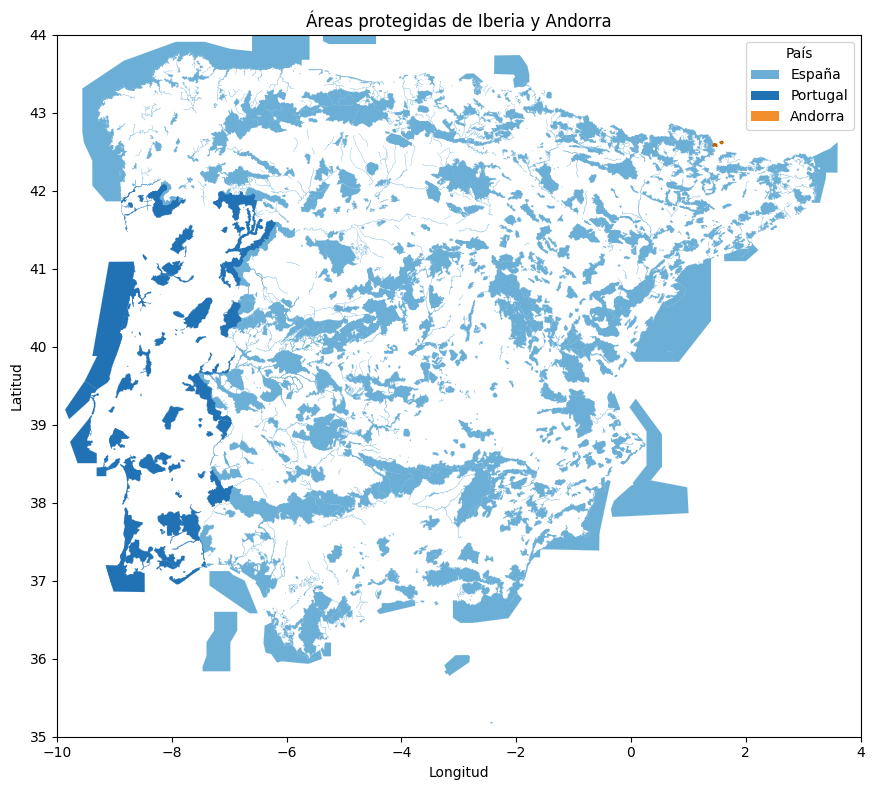

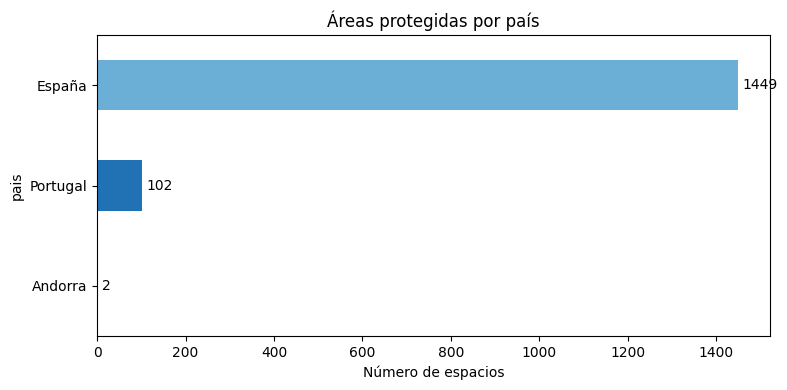

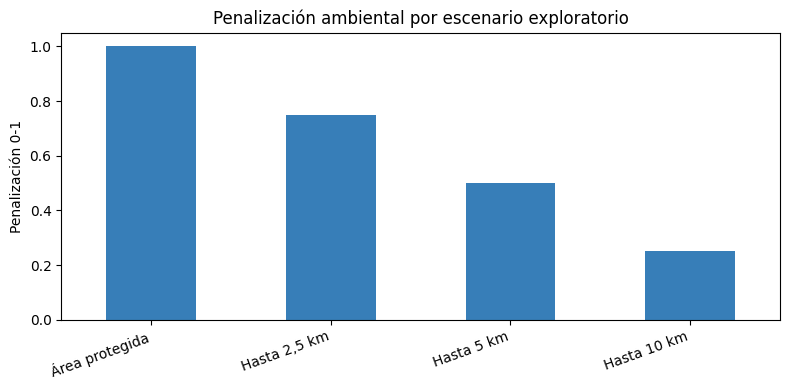

Visualizaciones guardadas en: /kaggle/working/05_restricciones_ambientales_areas_protegidas/dashboard


In [12]:
# visualizaciones de control
from matplotlib.patches import Patch

# preparamos una capa para visualizar
capa_mapa = areas_protegidas_integradas.to_crs(
    CRS_EUROPEO_AREA
).copy()

capa_mapa["geometry"] = capa_mapa.geometry.simplify(
    100,
    preserve_topology=True
)

capa_mapa = capa_mapa.to_crs(CRS_GEOGRAFICO)


# rutas
ruta_mapa = (
    DASHBOARD_DIR / "mapa_areas_protegidas_iberia.png"
)
ruta_grafico_paises = (
    DASHBOARD_DIR / "grafico_areas_protegidas_por_pais.png"
)
ruta_grafico_penalizacion = (
    DASHBOARD_DIR / "grafico_penalizacion_ambiental.png"
)

colores_paises = {
    "España": "#6baed6",
    "Portugal": "#2171b5",
    "Andorra": "#f28e2b"
}

# mapa de áreas protegidas
fig, ax = plt.subplots(figsize=(11, 8))

for pais, color in colores_paises.items():
    datos_pais = capa_mapa[
        capa_mapa["pais"] == pais
    ]
    datos_pais.plot(
        ax=ax,
        color=color,
        edgecolor="#b85c00" if pais == "Andorra" else color,
        linewidth=0.8 if pais == "Andorra" else 0.1,
        zorder=3 if pais == "Andorra" else 1
    )

leyenda = [
    Patch(
        facecolor=color,
        label=pais
    )
    for pais, color in colores_paises.items()
]
ax.legend(
    handles=leyenda,
    title="País"
)
ax.set(
    title="Áreas protegidas de Iberia y Andorra",
    xlabel="Longitud",
    ylabel="Latitud",
    xlim=(OESTE, ESTE),
    ylim=(SUR, NORTE)
)

plt.tight_layout()
plt.savefig(ruta_mapa, dpi=180)
plt.show()
plt.close()


# áreas protegidas por país
conteo_paises = (
    areas_protegidas_integradas["pais"]
    .value_counts()
    .sort_values()
)

colores_barras = [
    colores_paises[pais]
    for pais in conteo_paises.index
]
ax = conteo_paises.plot.barh(
    color=colores_barras,
    figsize=(8, 4),
    title="Áreas protegidas por país"
)
ax.bar_label(
    ax.containers[0],
    padding=3
)

plt.xlabel("Número de espacios")
plt.tight_layout()
plt.savefig(ruta_grafico_paises, dpi=180)
plt.show()
plt.close()

# penalización por escenario
ax = indicador_restriccion_ambiental_modelo.plot.bar(
    x="escenario_restriccion",
    y="penalizacion_ambiental_0_1",
    color="#377eb8",
    legend=False,
    figsize=(8, 4),
    title="Penalización ambiental por escenario exploratorio"
)
ax.set(
    xlabel="",
    ylabel="Penalización 0-1",
    ylim=(0, 1.05)
)

etiquetas = [
    "Área protegida",
    "Hasta 2,5 km",
    "Hasta 5 km",
    "Hasta 10 km"
]

ax.set_xticklabels(
    etiquetas,
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.savefig(ruta_grafico_penalizacion, dpi=180)
plt.show()
plt.close()

print("Visualizaciones guardadas en:", DASHBOARD_DIR)

# Dashboard HTML autónomo

Generamos un dashboard HTML que reúne el resumen del bloque, los cuatro escenarios de penalización ambiental y las visualizaciones de control.

Incorporamos las imágenes en Base64 para poder abrir y compartir el dashboard como un único archivo.

El resumen incluye los 1.553 espacios protegidos de España, Portugal y Andorra. Calculamos los cuatro escenarios de penalización sobre los 1.551 espacios Natura 2000 comparables de España y Portugal.

Mostramos los dos espacios Emerald de Andorra como información ambiental complementaria y no forman parte del indicador comparable.


In [13]:
# dashboard
import base64

def img64(ruta):
    return (
        "data:image/png;base64,"
        + base64.b64encode(ruta.read_bytes()).decode()
    )

imagenes = {
    "Áreas protegidas de Iberia y Andorra":
        DASHBOARD_DIR / "mapa_areas_protegidas_iberia.png",
    "Áreas protegidas por país":
        DASHBOARD_DIR / "grafico_areas_protegidas_por_pais.png",
    "Penalización ambiental exploratoria":
        DASHBOARD_DIR / "grafico_penalizacion_ambiental.png"
}

bloque_imagenes = ""

for titulo, ruta in imagenes.items():
    if not ruta.exists():
        raise FileNotFoundError(ruta)
    bloque_imagenes += (
        f"<h2>{titulo}</h2>"
        f'<img src="{img64(ruta)}">'
    )

html = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Restricciones ambientales</title>
<style>
body {{font-family:Arial; max-width:1100px; margin:auto;}}
img {{width:100%; margin-bottom:25px;}}
table {{border-collapse:collapse; width:100%;}}
th, td {{border:1px solid #ccc; padding:7px;}}
</style>
</head>

<body>

<h1>Bloque 05 · Restricciones ambientales</h1>

<h2>Resumen</h2>
{resumen_bloque_05.to_html(index=False)}

<h2>Escenarios ambientales</h2>
{indicador_restriccion_ambiental_modelo.to_html(index=False)}

{bloque_imagenes}

<p>
El resumen incluye 1.553 espacios protegidos.
Los escenarios de penalización se calculan con los 1.551
espacios Natura 2000 de España y Portugal.
Los dos espacios Emerald de Andorra se mantienen como
información ambiental complementaria.
Los buffers son exploratorios y no representan distancias legales.
</p>

</body>
</html>
"""

ruta_dashboard_html = (
    DASHBOARD_DIR
    / "dashboard_bloque_05_restricciones_ambientales_areas_protegidas.html"
)
ruta_dashboard_html.write_text(
    html,
    encoding="utf-8"
)

print("Dashboard guardado en:", ruta_dashboard_html)

Dashboard guardado en: /kaggle/working/05_restricciones_ambientales_areas_protegidas/dashboard/dashboard_bloque_05_restricciones_ambientales_areas_protegidas.html


# Inventario final

Comprobamos las principales salidas del bloque antes de crear el ZIP:

* capas GeoPackage;
* tablas CSV;
* visualizaciones PNG;
* dashboard HTML.

El inventario registra la ruta, el tipo, el tamaño y la existencia de cada archivo. Sirve como control final de las salidas y no modifica los datos procesados.

In [14]:
# inventario final
rutas_finales = [
    ruta_areas_integradas,
    ruta_gpkg_modelo_unicas,
    ruta_gpkg_restricciones,
    ruta_fuentes_ambientales,
    ruta_indicador_modelo_processed,
    ruta_resumen_general_processed,
    ruta_resumen_fases_processed,
    ruta_mapa,
    ruta_grafico_paises,
    ruta_grafico_penalizacion,
    ruta_dashboard_html
]

inventario_archivos = pd.DataFrame({
    "archivo": [ruta.name for ruta in rutas_finales],
    "tipo": [ruta.suffix.lower() for ruta in rutas_finales],
    "ruta": [str(ruta) for ruta in rutas_finales],
    "existe": [ruta.exists() for ruta in rutas_finales],
    "tamano_mb": [
        round(ruta.stat().st_size / 1024**2, 3)
        if ruta.exists() else 0
        for ruta in rutas_finales
    ]
})

ruta_inventario = (
    TABLAS_DIR / "tabla_inventario_archivos_bloque_05.csv"
)

inventario_archivos.to_csv(
    ruta_inventario,
    index=False
)

if not inventario_archivos["existe"].all():
    raise FileNotFoundError(
        "Faltan archivos principales."
    )

print("Archivos comprobados:", len(inventario_archivos))
display(inventario_archivos)

Archivos comprobados: 11


,archivo,tipo,ruta,existe,tamano_mb
0,areas_protegidas_integradas_iberia_andorra.gpkg,.gpkg,/kaggle/working/05_restricciones_ambientales_a...,True,168.609
1,areas_protegidas_modelo_sitios_unicos.gpkg,.gpkg,/kaggle/working/05_restricciones_ambientales_a...,True,168.590
2,indicador_restriccion_ambiental_areas_protegid...,.gpkg,/kaggle/working/05_restricciones_ambientales_a...,True,178.738
3,tabla_fuentes_ambientales.csv,.csv,/kaggle/working/05_restricciones_ambientales_a...,True,0.001
4,indicador_restriccion_ambiental_modelo_final.csv,.csv,/kaggle/working/05_restricciones_ambientales_a...,True,0.000
5,resumen_general_bloque_05_areas_protegidas.csv,.csv,/kaggle/working/05_restricciones_ambientales_a...,True,0.000
6,resumen_fases_bloque_05.csv,.csv,/kaggle/working/05_restricciones_ambientales_a...,True,0.000
7,mapa_areas_protegidas_iberia.png,.png,/kaggle/working/05_restricciones_ambientales_a...,True,0.686
8,grafico_areas_protegidas_por_pais.png,.png,/kaggle/working/05_restricciones_ambientales_a...,True,0.034
9,grafico_penalizacion_ambiental.png,.png,/kaggle/working/05_restricciones_ambientales_a...,True,0.051


# ZIP final

Creamos un ZIP con los 11 archivos principales:

* capas GeoPackage;
* tablas CSV;
* visualizaciones PNG;
* dashboard HTML.

No incluimos archivos RAW ni salidas intermedias. El paquete reúne las salidas principales necesarias para reutilizar los resultados del bloque.

Para mantener la compatibilidad con el Notebook 10 conservamos la capa de 1.551 espacios Natura 2000 y la tabla con los cuatro escenarios de penalización ambiental.

In [15]:
# ZIP final
import zipfile

ruta_zip_final = (
    OUT_DIR.parent
    / "05_restricciones_ambientales_areas_protegidas_entrega_limpia.zip"
)

with zipfile.ZipFile(
    ruta_zip_final,
    "w",
    zipfile.ZIP_DEFLATED
) as archivo_zip:

    for ruta in rutas_finales:
        archivo_zip.write(
            ruta,
            arcname=Path(OUT_DIR.name)
            / ruta.relative_to(OUT_DIR)
        )


# comprobación
with zipfile.ZipFile(ruta_zip_final) as archivo_zip:
    contenido_zip = archivo_zip.namelist()

    if len(contenido_zip) != 11:
        raise RuntimeError("El ZIP no contiene los 11 archivos esperados.")

    if archivo_zip.testzip() is not None:
        raise RuntimeError("El ZIP contiene algún archivo dañado.")


print("ZIP:", ruta_zip_final)
print("Archivos:", len(contenido_zip))
print(
    "Tamaño MB:",
    round(ruta_zip_final.stat().st_size / 1024**2, 2)
)

ZIP: /kaggle/working/05_restricciones_ambientales_areas_protegidas_entrega_limpia.zip
Archivos: 11
Tamaño MB: 341.65


# Interpretación metodológica final

En este notebook preparamos las restricciones ambientales que usaremos después en el modelo multicriterio del TFB.

Integramos 1.553 espacios protegidos como resultado descriptivo:

* 1.449 espacios Natura 2000 de España;
* 102 espacios Natura 2000 de Portugal;
* 2 espacios Emerald de Andorra.

Para el análisis comparable recogemos los 1.551 espacios Natura 2000 de España y Portugal y definimos cuatro escenarios de penalización:

* dentro del área protegida: 1,00;
* hasta 2,5 km: 0,75;
* hasta 5 km: 0,50;
* hasta 10 km: 0,25.

La capa `areas_protegidas_integradas` conserva los 1.553 espacios como información descriptiva. La capa `areas_protegidas_modelo_unicas` contiene los 1.551 espacios comparables que utiliza después el NB10.

Los dos espacios Emerald de Andorra los mantenemos como información ambiental complementaria y Andorra continúa como territorio no comparable para esta dimensión.

En el NB10 estos escenarios los ttrasnformamos en bandas territoriales exclusivas y calculamos`ambiental_penalizacion_media_0_1`, que es la variable usada  en la dimensión de Medio ambiente del IIT-CPD.

Las superficies pueden incluir solapes y los buffers son escenarios exploratorios, no distancias legales. Este análisis no sustituye una evaluación ambiental oficial ni una comprobación jurídica de parcelas concretas.